# RC-HAVOK A/B Rounding Ablation Study

**Purpose:** Formally isolate the contribution of A-matrix rounding versus B-vector rounding  
to free-run reconstruction degradation in the RC-HAVOK framework.

## Four ablation cases

| Case | A matrix | B vector | Purpose |
|------|----------|----------|---------|
| Modified (float/float) | Float | Float | Best-case reference |
| Original (round/round) | Rounded | Rounded | Base-paper original |
| A-rounded only | Rounded | Float | Isolate A damage |
| B-rounded only | Float | Rounded | Isolate B damage |

Each case is evaluated for **both PWL and cubic Chua** across **10 random seeds**.

## Hypotheses
- **H1:** A-rounding is the primary damage mechanism (alters eigenfrequencies of the identified linear operator).
- **H2:** B-rounding causes secondary but measurable degradation (affects forcing amplitude).
- **H3:** A-round-only performance is close to Original (round/round), confirming H1.

## Locked parameters (DO NOT MODIFY)
```
Chua: alpha=9, beta=100/7, m0=-1/7, m1=2/7, IC=(0.1,0.2,0.1)
Reservoir: N=500, sr=0.9, conn=0.200, leakage=0.400
HAVOK: rank=4, Hankel delays=200
Evaluation: forward-Euler free-run, last 25% of trajectory
T_END=200s, dt=0.001, N_SEEDS=10
```

**Wording conventions:**
- Use 'bounded double-scroll-like trajectory' — not 'confirmed chaos'
- Use 'supports' / 'suggests' — not 'proves'
- Report median R² and mean ± SD separately

---
> **Restart kernel → Run All** reproduces all results from scratch.

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('Agg')  # commented out for Colab/notebook display
                         # uncomment if running headless (no display)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.sparse import random as sparse_random
from sklearn.metrics import r2_score, mean_squared_error
from numpy.lib.stride_tricks import sliding_window_view
import time
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — CONFIGURATION  (locked — do not modify for reported results)
# ═══════════════════════════════════════════════════════════════════

# ── Run settings ────────────────────────────────────────────────────
T_END          = 200.0          # seconds — matches base reproduction
DT             = 0.001
BURN_IN        = 2000           # washout steps
EVAL_SECONDS   = 13.0           # 13-second free-run window
                                # (consistent with earlier PWL/cubic/noise notebooks)
N_SEEDS        = 10             # final run (increase to 20 for stronger seed stats)
                               #   (was 2 for smoke test)
MAX_STATE_NORM = 1e3            # divergence threshold
MIN_HANKEL_STD = 1e-6           # degenerate reservoir detection
INPUT_SCALE    = 0.1            # paper Table I: u = [0.1, 0.1·x]
HANKEL_DELAYS  = 200            # Hankel row count

# ── Chua parameters (sign-corrected, see Methods §III-A) ────────────
ALPHA, BETA = 9.0, 100.0 / 7.0
M0, M1      = -1.0 / 7.0, 2.0 / 7.0   # sign-corrected m0
INIT_STATE  = [0.1, 0.2, 0.1]

# ── Locked baseline reservoir + HAVOK config ────────────────────────
CFG = dict(
    n_reservoir    = 500,
    spectral_radius= 0.9,
    connectivity   = 0.200,
    leakage        = 0.400,
    havok_rank     = 4,
)

SYSTEMS = ['pwl', 'cubic']

# ── Ablation case definitions ────────────────────────────────────────
# Each case is (label, round_A, round_B, colour)
CASES = [
    ('Modified\n(float/float)',   False, False, '#2166ac'),
    ('A-rounded\nonly',           True,  False, '#f4a582'),
    ('B-rounded\nonly',           False, True,  '#92c5de'),
    ('Original\n(round/round)',   True,  True,  '#d6604d'),
]
CASE_LABELS  = [c[0] for c in CASES]
CASE_COLOURS = [c[3] for c in CASES]

print(f'T_END={T_END}s | DT={DT} | BURN_IN={BURN_IN} | EVAL={EVAL_SECONDS}s (fixed window)')
print(f'N_SEEDS={N_SEEDS} | HANKEL_DELAYS={HANKEL_DELAYS}')
print(f'Chua: alpha={ALPHA}, beta={BETA:.4f}, m0={M0:.6f}, m1={M1:.6f}')
print(f'Reservoir: {CFG}')
print(f'\nAblation cases:')
for label, ra, rb, _ in CASES:
    print(f'  {label.replace(chr(10)," "):30s}  round_A={ra}  round_B={rb}')

T_END=200.0s | DT=0.001 | BURN_IN=2000 | EVAL=13.0s (fixed window)
N_SEEDS=10 | HANKEL_DELAYS=200
Chua: alpha=9.0, beta=14.2857, m0=-0.142857, m1=0.285714
Reservoir: {'n_reservoir': 500, 'spectral_radius': 0.9, 'connectivity': 0.2, 'leakage': 0.4, 'havok_rank': 4}

Ablation cases:
  Modified (float/float)          round_A=False  round_B=False
  A-rounded only                  round_A=True  round_B=False
  B-rounded only                  round_A=False  round_B=True
  Original (round/round)          round_A=True  round_B=True


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — CHUA TRAJECTORY GENERATION
# ═══════════════════════════════════════════════════════════════════

def h_pwl(x):
    """Piecewise-linear Chua diode (sign-corrected, m0 = -1/7)."""
    return M1*x + 0.5*(M0 - M1)*(np.abs(x + 1) - np.abs(x - 1))

def h_cubic(x):
    """Smooth cubic Chua-type diode: h(x) = x³/16 - x/6."""
    return x**3 / 16.0 - x / 6.0

def chua_rhs(t, s, h_func):
    x, y, z = s
    return [ALPHA*(y - h_func(x)), x - y + z, -BETA*y]

def generate_chua(system):
    h    = h_pwl if system == 'pwl' else h_cubic
    t_ev = np.arange(0.0, T_END, DT)
    sol  = solve_ivp(chua_rhs, [0.0, T_END], INIT_STATE,
                     t_eval=t_ev, args=(h,),
                     method='RK45', rtol=1e-9, atol=1e-9)
    if not sol.success:
        raise RuntimeError(f'{system} solve_ivp failed: {sol.message}')
    return sol.y[0]

print('Generating Chua trajectories (RK45, rtol=atol=1e-9) ...')
SYS_DATA = {}
for sys in SYSTEMS:
    x = generate_chua(sys)
    SYS_DATA[sys] = x
    ok = np.all(np.isfinite(x)) and (x.max() - x.min()) > 0.1
    print(f'  {sys:5s}: N={len(x):,}  std={x.std():.4f}  '
          f'range=[{x.min():.3f}, {x.max():.3f}]  OK={ok}')

print('Chua generation complete.')

Generating Chua trajectories (RK45, rtol=atol=1e-9) ...
  pwl  : N=200,000  std=1.3733  range=[-2.242, 2.240]  OK=True
  cubic: N=200,000  std=1.3223  range=[-2.143, 2.145]  OK=True
Chua generation complete.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — RESERVOIR COMPUTING (ESN)
# ═══════════════════════════════════════════════════════════════════

def _spectral_radius_power(W, n_iter=20, seed=0):
    """Power-iteration spectral radius estimate (~23× faster than eigs)."""
    rng = np.random.default_rng(seed)
    v   = rng.random(W.shape[0]); v /= np.linalg.norm(v)
    nrm = 1.0
    for _ in range(n_iter):
        v   = W @ v
        nrm = np.linalg.norm(v)
        if nrm < 1e-14: return 0.0
        v  /= nrm
    return float(nrm)

def create_reservoir(n, conn, sr, seed):
    """Build sparse Win and Wr; scale Wr to target spectral radius."""
    rng = np.random.default_rng(seed)
    Win = 2.0 * rng.random((n, 2)) - 1.0
    Wr  = sparse_random(n, n, density=conn, format='csr',
                        data_rvs=rng.random)
    r   = _spectral_radius_power(Wr, seed=seed)
    if r > 1e-12:
        Wr = Wr * (sr / r)
    return Win, Wr

def run_reservoir(x, n, conn, sr, lk, seed):
    """
    ESN state update:
        s(k+1) = (1 - lk)*s(k) + tanh(Wr @ s(k) + Win @ u(k+1))
    Input vector: u(k) = [0.1, 0.1·x(k)]  (paper Table I convention).
    """
    Win, Wr = create_reservoir(n, conn, sr, seed)
    N       = len(x)
    s       = np.zeros(n)
    states  = np.zeros((N, n), dtype=np.float32)
    for k in range(1, N):
        u      = np.array([INPUT_SCALE, INPUT_SCALE * x[k]])
        pre    = Wr @ s + Win @ u
        s      = (1.0 - lk) * s + np.tanh(pre)
        states[k] = s.astype(np.float32)
    return states

print('Reservoir functions defined.')

Reservoir functions defined.


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — HANKEL CONSTRUCTION + HAVOK FITTING
# ═══════════════════════════════════════════════════════════════════

def build_hankel(states, delays=HANKEL_DELAYS, burn_in=BURN_IN):
    """
    Build Hankel matrix from the first reservoir-state component (column 0).
    Raises ValueError if observable std < MIN_HANKEL_STD (degenerate reservoir).
    """
    g     = states[burn_in:, 0].astype(np.float64)
    g_std = g.std()
    if g_std < MIN_HANKEL_STD:
        raise ValueError(f'Degenerate reservoir: std={g_std:.2e} < {MIN_HANKEL_STD}')
    g = (g - g.mean()) / g_std   # z-score normalise
    return sliding_window_view(g, delays).T.copy()  # shape: (delays, n_windows)

def fit_havok(H, rank):
    """
    HAVOK fitting with exact full SVD (np.linalg.svd).

    Returns
    -------
    A_float  : (r-1)×(r-1) float operator
    B_float  : (r-1,) float forcing vector
    X        : (T, r-1) temporal state modes
    forcing  : (T,) forcing coordinate (v_r)
    S        : singular values
    """
    U, S, Vt  = np.linalg.svd(H, full_matrices=False)   # exact SVD
    V         = Vt.T[:, :rank]

    # ── SVD sign convention (Fix 4 from reviewer) ─────────────────
    # Each singular vector is defined up to a sign flip.
    # Enforce: the element with largest absolute value in each
    # mode column is positive. This stabilises the integer A/B
    # matrices across seeds, making unique-A/B counts interpretable.
    for j in range(V.shape[1]):
        idx = np.argmax(np.abs(V[:, j]))
        if V[idx, j] < 0:
            V[:, j] *= -1

    dV        = np.gradient(V, DT, axis=0)
    X         = V[:, :rank - 1]
    forcing   = V[:, rank - 1]
    dX        = dV[:, :rank - 1]
    Theta     = np.hstack([X, forcing.reshape(-1, 1)])
    Xi, *_    = np.linalg.lstsq(Theta, dX, rcond=None)
    A_float   = Xi[:rank - 1, :].T          # (r-1)×(r-1)
    B_float   = Xi[rank - 1, :].T           # (r-1,)
    return A_float, B_float, X, forcing, S

def apply_rounding(A_float, B_float, round_A, round_B):
    """
    Return (A, B) according to ablation case specification.
    round_A / round_B are booleans.
    """
    A = np.round(A_float) if round_A else A_float.copy()
    B = np.round(B_float) if round_B else B_float.copy()
    return A, B

print('Hankel + HAVOK functions defined.')

Hankel + HAVOK functions defined.


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — EVALUATION METRICS
# ═══════════════════════════════════════════════════════════════════

def free_run_metrics(X, forcing, A, B):
    """
    Forced free-run HAVOK-coordinate reconstruction.

    Integration method: forward Euler at dt=DT.
    Forcing coordinate v_r is supplied from the SVD decomposition
    at each step (observed, not predicted).
    Evaluation: fixed EVAL_SECONDS window (consistent with prior notebooks).

    Returns
    -------
    r2      : float  (R² on all state modes)
    rmse    : float
    mae     : float
    diverged: bool
    """
    n      = X.shape[0]
    n_eval = max(int(EVAL_SECONDS / DT), 10)  # fixed 13s window
    start  = n - n_eval

    Xhat      = np.zeros((n_eval, X.shape[1]))
    Xhat[0]   = X[start]

    for k in range(1, n_eval):
        dx      = A @ Xhat[k - 1] + B * forcing[start + k - 1]
        Xhat[k] = Xhat[k - 1] + dx * DT
        if (not np.all(np.isfinite(Xhat[k])) or
                np.max(np.abs(Xhat[k])) > MAX_STATE_NORM):
            return np.nan, np.nan, np.nan, True

    y_true = X[start:start + n_eval]
    if np.var(y_true) < 1e-20:
        return np.nan, np.nan, np.nan, False

    r2   = r2_score(y_true, Xhat)
    rmse = float(np.sqrt(mean_squared_error(y_true, Xhat)))
    mae  = float(np.mean(np.abs(y_true - Xhat)))
    return r2, rmse, mae, False

def eigenvalue_info(A):
    """
    Return (max real part, dominant imaginary frequency) of A's eigenvalues.
    The dominant imaginary part corresponds to the oscillation frequency
    of the identified linear system.
    """
    eigs = np.linalg.eigvals(A)
    max_real = float(np.max(np.real(eigs)))
    dom_freq = float(np.max(np.abs(np.imag(eigs))))   # rad/s
    return max_real, dom_freq, eigs

print('Metric functions defined.')

Metric functions defined.


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — PER-SEED RUNNER
# ═══════════════════════════════════════════════════════════════════

def run_one_seed(system, seed):
    """
    Run full RC-HAVOK pipeline for one seed and return metrics
    for all four ablation cases.

    Returns list of dicts, one per case.
    """
    cfg = CFG
    results = []

    try:
        x = SYS_DATA[system]

        # ── Reservoir ──────────────────────────────────────────────
        states = run_reservoir(x,
                               cfg['n_reservoir'],
                               cfg['connectivity'],
                               cfg['spectral_radius'],
                               cfg['leakage'],
                               seed)

        # ── Hankel + HAVOK (exact SVD, float A/B) ──────────────────
        H = build_hankel(states, delays=HANKEL_DELAYS)
        A_f, B_f, X, forcing, S = fit_havok(H, cfg['havok_rank'])

        # ── Eigenvalue analysis on float A ─────────────────────────
        lam_max_f, freq_f, eigs_f = eigenvalue_info(A_f)
        # Rounded A eigenvalues (for comparison)
        A_r = np.round(A_f)
        lam_max_r, freq_r, eigs_r = eigenvalue_info(A_r)

        # ── B statistics ───────────────────────────────────────────
        B_r = np.round(B_f)
        B_norm_f = float(np.linalg.norm(B_f))
        B_norm_r = float(np.linalg.norm(B_r))
        max_B_f  = float(np.max(np.abs(B_f)))

        # ── Four ablation cases ────────────────────────────────────
        for case_label, round_A, round_B, _ in CASES:
            A_use, B_use = apply_rounding(A_f, B_f, round_A, round_B)
            r2, rmse, mae, div = free_run_metrics(X, forcing, A_use, B_use)
            lam_max_use, freq_use, _ = eigenvalue_info(A_use)

            results.append(dict(
                system      = system,
                seed        = seed,
                case        = case_label.replace('\n', ' '),
                round_A     = round_A,
                round_B     = round_B,
                r2          = r2,
                rmse        = rmse,
                mae         = mae,
                diverged    = div,
                lam_max     = lam_max_use,
                dom_freq    = freq_use,
                # Additional diagnostics (same for all cases, reflects A_f)
                lam_max_float  = lam_max_f,
                freq_float     = freq_f,
                lam_max_round  = lam_max_r,
                freq_round     = freq_r,
                freq_shift     = abs(freq_f - freq_r),
                B_norm_float   = B_norm_f,
                B_norm_round   = B_norm_r,
                max_B_float    = max_B_f,
                sv0            = float(S[0]),
                sv1            = float(S[1]),
                A_float_str    = str(np.round(A_f, 4).tolist()),
                A_round_str    = str(A_r.astype(int).tolist()),
                B_float_str    = str(np.round(B_f, 4).tolist()),
                B_round_str    = str(B_r.astype(int).tolist()),
                failure        = False,
            ))

    except Exception as e:
        print(f'  [WARN] {system} seed={seed}: {e}')
        for case_label, round_A, round_B, _ in CASES:
            nan = float('nan')
            results.append(dict(
                system=system, seed=seed,
                case=case_label.replace('\n',' '),
                round_A=round_A, round_B=round_B,
                r2=nan, rmse=nan, mae=nan, diverged=True,
                lam_max=nan, dom_freq=nan,
                lam_max_float=nan, freq_float=nan,
                lam_max_round=nan, freq_round=nan, freq_shift=nan,
                B_norm_float=nan, B_norm_round=nan, max_B_float=nan,
                sv0=nan, sv1=nan,
                A_float_str='', A_round_str='',
                B_float_str='', B_round_str='',
                failure=True,
            ))

    return results

print('Per-seed runner defined.')

Per-seed runner defined.


In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — MAIN ABLATION SWEEP
# ═══════════════════════════════════════════════════════════════════

print('=' * 65)
print('RC-HAVOK A/B ROUNDING ABLATION SWEEP')
print(f'T_END={T_END}s | {N_SEEDS} seeds | 4 cases | 2 systems')
print('=' * 65)

all_records = []

for system in SYSTEMS:
    print(f'\n─── {system.upper()} Chua ──────────────────────────────────────')
    for seed in range(N_SEEDS):
        t0      = time.time()
        records = run_one_seed(system, seed)
        elapsed = time.time() - t0
        all_records.extend(records)

        # Print one-line summary for this seed
        r2_by_case = {r['case']: r['r2'] for r in records}
        div_by_case = {r['case']: r['diverged'] for r in records}
        cases_short = ['Modified (float/float)', 'A-rounded only',
                       'B-rounded only', 'Original (round/round)']
        r2_vals = [f"{r2_by_case.get(c, float('nan')):.4f}" for c in cases_short]
        div_vals = [('DIV' if div_by_case.get(c, True) else 'ok') for c in cases_short]
        print(f'  seed={seed}: R²= {" | ".join(r2_vals)} '
              f'  [{" | ".join(div_vals)}]  ({elapsed:.1f}s)')

df = pd.DataFrame(all_records)
print(f'\nTotal records: {len(df)}  ({len(SYSTEMS)} systems × {N_SEEDS} seeds × {len(CASES)} cases)')
print('Sweep complete.')

RC-HAVOK A/B ROUNDING ABLATION SWEEP
T_END=200.0s | 10 seeds | 4 cases | 2 systems

─── PWL Chua ──────────────────────────────────────
  seed=0: R²= 0.9818 | -0.0247 | 0.9856 | -0.0389   [ok | ok | ok | ok]  (40.8s)
  seed=1: R²= 0.9830 | -0.0521 | 0.9900 | -0.0821   [ok | ok | ok | ok]  (33.4s)
  seed=2: R²= 0.9817 | -0.0239 | 0.9848 | -0.0359   [ok | ok | ok | ok]  (34.9s)
  seed=3: R²= 0.9784 | -0.3549 | 0.9809 | -0.3665   [ok | ok | ok | ok]  (33.1s)
  seed=4: R²= 0.9788 | -1.0993 | 0.9847 | -1.1429   [ok | ok | ok | ok]  (34.5s)
  seed=5: R²= 0.9822 | -0.0272 | 0.9867 | -0.0449   [ok | ok | ok | ok]  (33.3s)
  seed=6: R²= 0.9816 | -0.0219 | 0.9843 | -0.0323   [ok | ok | ok | ok]  (32.9s)
  seed=7: R²= 0.9827 | -0.0398 | 0.9887 | -0.0646   [ok | ok | ok | ok]  (34.5s)
  seed=8: R²= 0.9833 | -0.0645 | 0.9910 | -0.0993   [ok | ok | ok | ok]  (33.7s)
  seed=9: R²= 0.9818 | -0.0240 | 0.9852 | -0.0373   [ok | ok | ok | ok]  (32.4s)

─── CUBIC Chua ──────────────────────────────────────

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — SUMMARY STATISTICS TABLE
# ═══════════════════════════════════════════════════════════════════

case_order = [c[0].replace('\n', ' ') for c in CASES]

summary_rows = []
for system in SYSTEMS:
    for case in case_order:
        sub = df[(df['system'] == system) & (df['case'] == case)]
        valid  = sub[sub['diverged'] == False]
        r2s    = valid['r2'].dropna()
        rmses  = valid['rmse'].dropna()
        maes   = valid['mae'].dropna()
        n_div  = int(sub['diverged'].sum())
        summary_rows.append(dict(
            System    = system.upper(),
            Case      = case,
            N_valid   = len(r2s),
            N_diverged= n_div,
            R2_median = np.median(r2s) if len(r2s) else np.nan,
            R2_mean   = np.mean(r2s)   if len(r2s) else np.nan,
            R2_std    = np.std(r2s)    if len(r2s) else np.nan,
            R2_min    = np.min(r2s)    if len(r2s) else np.nan,
            R2_max    = np.max(r2s)    if len(r2s) else np.nan,
            RMSE_median= np.median(rmses) if len(rmses) else np.nan,
            MAE_median = np.median(maes)  if len(maes) else np.nan,
        ))

df_summary = pd.DataFrame(summary_rows)

print('=' * 80)
print('SUMMARY STATISTICS — A/B Rounding Ablation')
print('=' * 80)
for system in SYSTEMS:
    print(f'\n{system.upper()} Chua:')
    sub = df_summary[df_summary['System'] == system.upper()]
    print(f'  {"Case":<35} {"Median R²":>10} {"Mean±SD":>18} {"RMSE(med)":>12} {"Div":>5}')
    print('  ' + '-'*82)
    for _, row in sub.iterrows():
        mean_sd = f"{row['R2_mean']:.5f} ± {row['R2_std']:.5f}"
        print(f'  {row["Case"]:<35} {row["R2_median"]:>10.5f} '
              f'{mean_sd:>18} {row["RMSE_median"]:>12.2e} '
              f'{row["N_diverged"]:>3}/{N_SEEDS}')

SUMMARY STATISTICS — A/B Rounding Ablation

PWL Chua:
  Case                                 Median R²            Mean±SD    RMSE(med)   Div
  ----------------------------------------------------------------------------------
  Modified (float/float)                 0.98180  0.98151 ± 0.00157     3.18e-04   0/10
  A-rounded only                        -0.03354 -0.17325 ± 0.32338     2.45e-03   0/10
  B-rounded only                         0.98541  0.98619 ± 0.00286     2.82e-04   0/10
  Original (round/round)                -0.05480 -0.19448 ± 0.33022     2.48e-03   0/10

CUBIC Chua:
  Case                                 Median R²            Mean±SD    RMSE(med)   Div
  ----------------------------------------------------------------------------------
  Modified (float/float)                 0.99963  0.99963 ± 0.00005     2.99e-05   0/10
  A-rounded only                        -1.83711 -1.69680 ± 0.78880     2.59e-03   0/10
  B-rounded only                         0.96283  0.95914 ± 0

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — EIGENVALUE AND FREQUENCY SHIFT ANALYSIS
# ═══════════════════════════════════════════════════════════════════
# This is the mechanistic core of the ablation.
# We check whether A-rounding shifts the dominant oscillation frequency,
# which would explain free-run divergence.

print('=' * 65)
print('EIGENVALUE / FREQUENCY ANALYSIS')
print('A-rounding effect on dominant imaginary frequency (rad/s)')
print('=' * 65)

for system in SYSTEMS:
    sub = df[(df['system'] == system) & (df['case'] == 'Modified (float/float)')]
    freq_f  = sub['freq_float'].dropna()
    freq_r  = sub['freq_round'].dropna()
    shift   = sub['freq_shift'].dropna()
    lam_f   = sub['lam_max_float'].dropna()
    lam_r   = sub['lam_max_round'].dropna()

    print(f'\n{system.upper()} Chua (across {N_SEEDS} seeds):')
    print(f'  Float A  — dominant freq  : {freq_f.mean():.6f} ± {freq_f.std():.6f} rad/s')
    print(f'  Rounded A — dominant freq : {freq_r.mean():.6f} ± {freq_r.std():.6f} rad/s')
    print(f'  Freq shift |Δω|           : {shift.mean():.6f} ± {shift.std():.6f} rad/s')
    print(f'  Float A  — max Re(λ)      : {lam_f.mean():.6f} ± {lam_f.std():.6f}')
    print(f'  Rounded A — max Re(λ)     : {lam_r.mean():.6f} ± {lam_r.std():.6f}')

    # B norm comparison
    B_nf = sub['B_norm_float'].dropna()
    B_nr = sub['B_norm_round'].dropna()
    print(f'  ||B|| float               : {B_nf.mean():.4f} ± {B_nf.std():.4f}')
    print(f'  ||B|| rounded             : {B_nr.mean():.4f} ± {B_nr.std():.4f}')

    # A matrix stability check — do all seeds round to same integer A?
    A_round_vals = sub['A_round_str'].value_counts()
    print(f'  Unique integer A matrices : {len(A_round_vals)}')
    for mat_str, cnt in A_round_vals.items():
        print(f'    {cnt} seeds → A_round = {mat_str}')

    B_round_vals = sub['B_round_str'].value_counts()
    print(f'  Unique integer B vectors  : {len(B_round_vals)}')
    for vec_str, cnt in B_round_vals.items():
        print(f'    {cnt} seeds → B_round = {vec_str}')

EIGENVALUE / FREQUENCY ANALYSIS
A-rounding effect on dominant imaginary frequency (rad/s)

PWL Chua (across 10 seeds):
  Float A  — dominant freq  : 2.628160 ± 0.021897 rad/s
  Rounded A — dominant freq : 2.236068 ± 0.000000 rad/s
  Freq shift |Δω|           : 0.392092 ± 0.021897 rad/s
  Float A  — max Re(λ)      : 0.001633 ± 0.000089
  Rounded A — max Re(λ)     : 0.000000 ± 0.000000
  ||B|| float               : 3.9338 ± 0.0285
  ||B|| rounded             : 4.0000 ± 0.0000
  Unique integer A matrices : 1
    10 seeds → A_round = [[0, 1, 0], [-1, 0, 2], [0, -2, 0]]
  Unique integer B vectors  : 1
    10 seeds → B_round = [0, 0, -4]

CUBIC Chua (across 10 seeds):
  Float A  — dominant freq  : 2.756492 ± 0.035012 rad/s
  Rounded A — dominant freq : 2.328689 ± 0.292893 rad/s
  Freq shift |Δω|           : 0.491171 ± 0.063254 rad/s
  Float A  — max Re(λ)      : 0.001622 ± 0.001177
  Rounded A — max Re(λ)     : 0.000000 ± 0.000000
  ||B|| float               : 2.3726 ± 0.1118
  ||B|| rounded

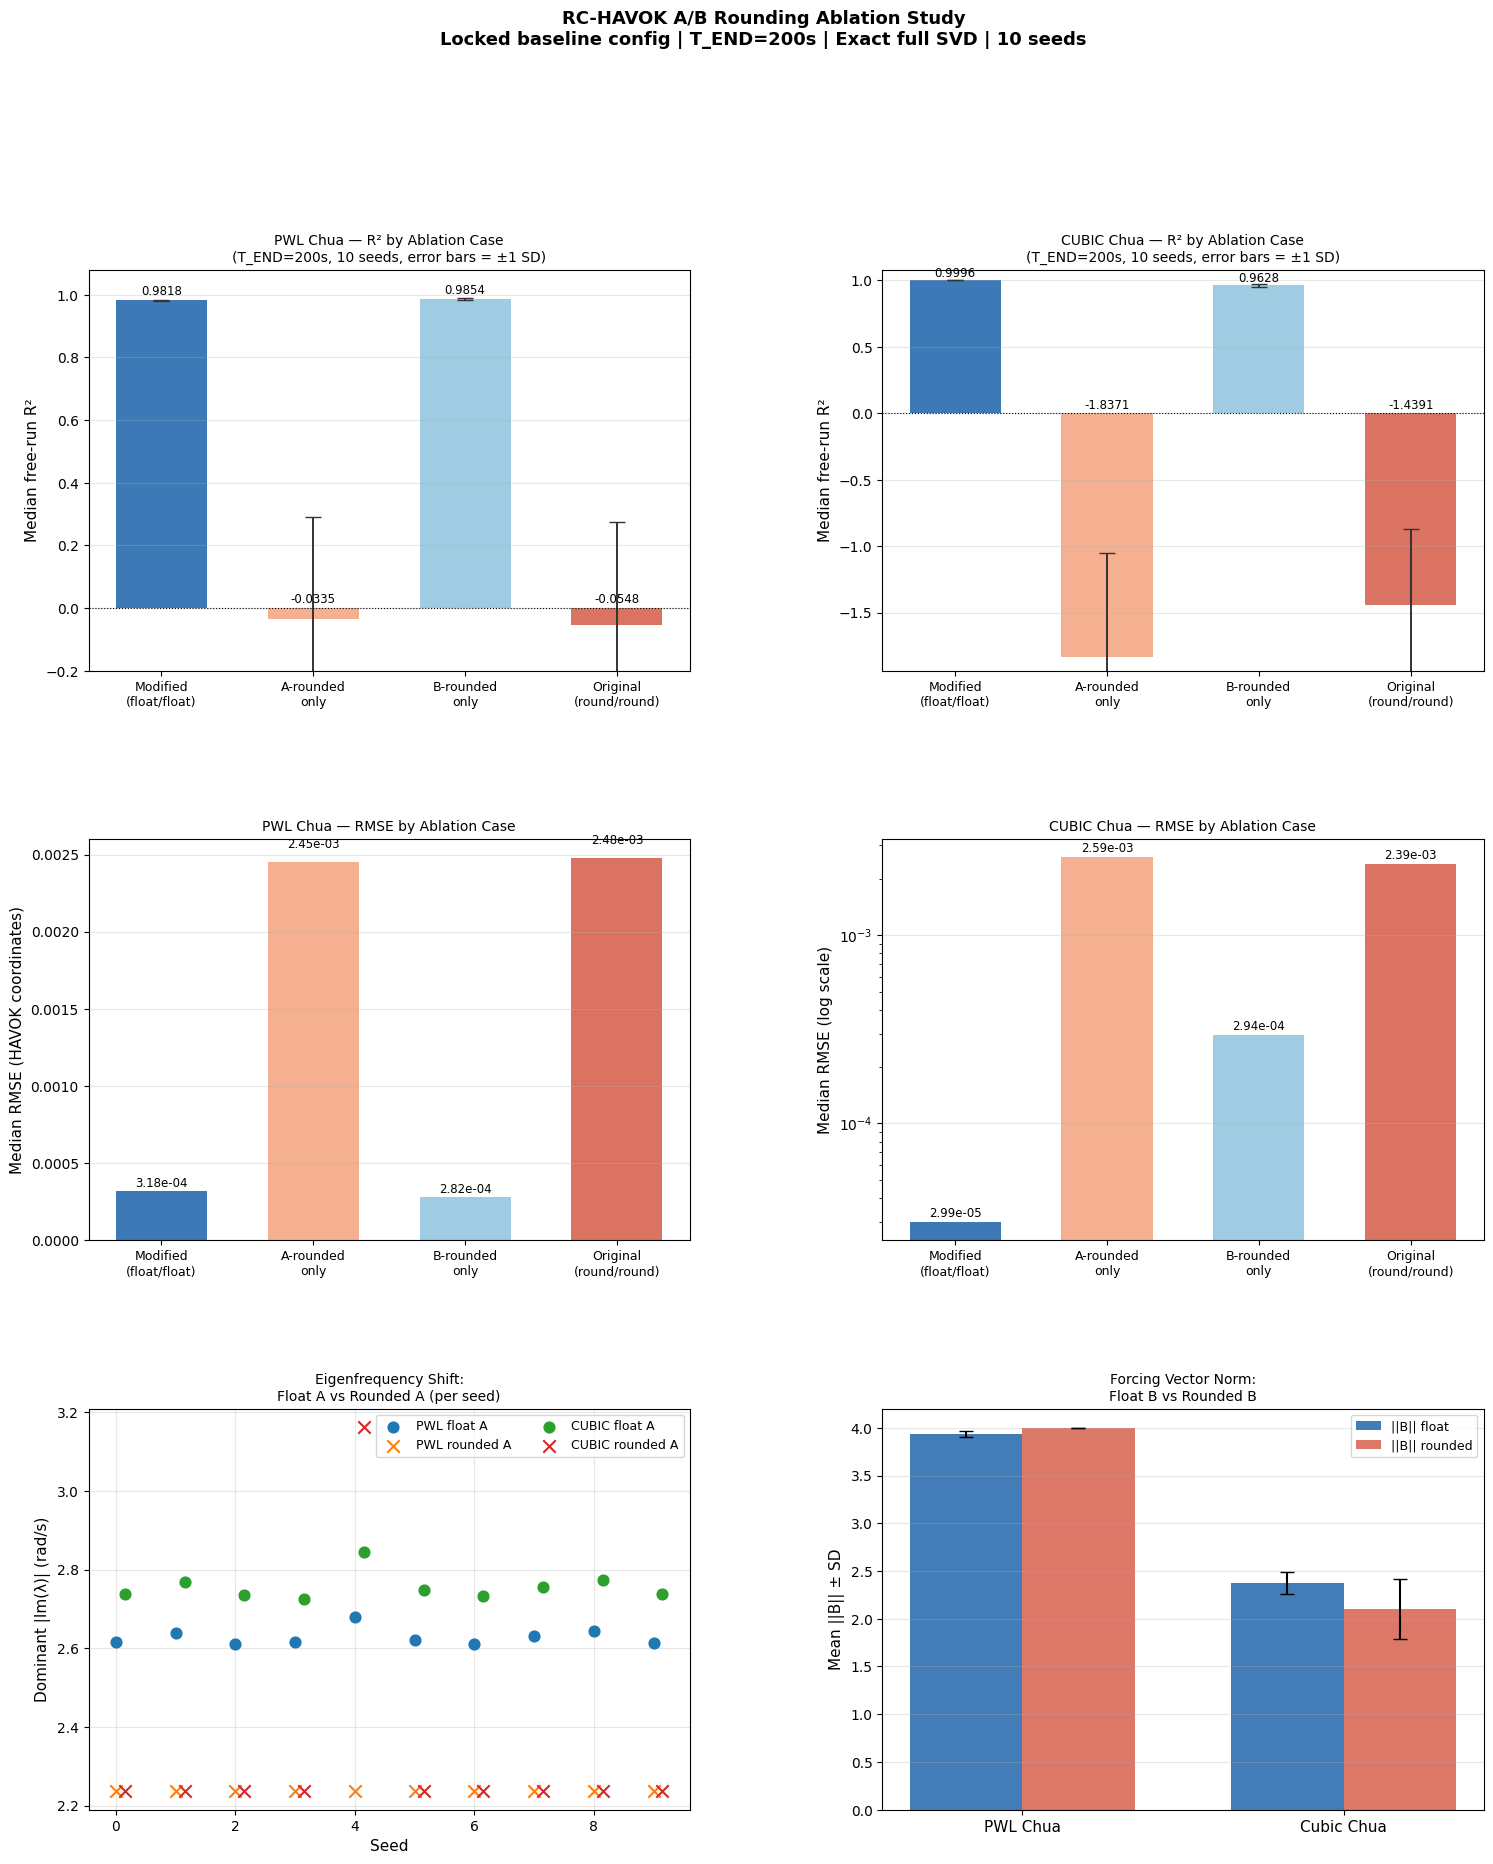

Saved: ablation_summary.png


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11 — PLOTS
# ═══════════════════════════════════════════════════════════════════

case_order_short = [c[0] for c in CASES]   # with newlines for tick labels
case_order_plain = [c[0].replace('\n', ' ') for c in CASES]

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Plot 1 & 2: Bar charts — Median R² per case (PWL / Cubic) ──────
for pi, system in enumerate(SYSTEMS):
    ax = fig.add_subplot(gs[0, pi])
    sub = df_summary[df_summary['System'] == system.upper()]
    x_pos = np.arange(len(CASES))
    bars  = ax.bar(x_pos,
                   sub['R2_median'].values,
                   yerr=sub['R2_std'].values,
                   color=CASE_COLOURS,
                   alpha=0.88, capsize=6, width=0.6,
                   error_kw=dict(elinewidth=1.4, ecolor='#333'))

    for bar, row in zip(bars, sub.itertuples()):
        h = bar.get_height()
        yoff = 0.008 if not np.isnan(h) else 0
        label = f'{h:.4f}' if not np.isnan(h) else 'DIV'
        ax.text(bar.get_x() + bar.get_width()/2,
                max(h, 0) + yoff,
                label, ha='center', va='bottom', fontsize=8.5)

    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(case_order_short, fontsize=9)
    ax.set_ylabel('Median free-run R²', fontsize=11)
    ax.set_title(f'{system.upper()} Chua — R² by Ablation Case\n'
                 f'(T_END=200s, {N_SEEDS} seeds, error bars = ±1 SD)', fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    ymin = min(sub['R2_median'].min() - 0.1, -0.2)
    ax.set_ylim(ymin, 1.08)

# ── Plot 3 & 4: RMSE bar charts ─────────────────────────────────────
for pi, system in enumerate(SYSTEMS):
    ax = fig.add_subplot(gs[1, pi])
    sub = df_summary[df_summary['System'] == system.upper()]
    x_pos = np.arange(len(CASES))

    # Only show non-NaN RMSE (diverged cases show as 0 bar with DIV label)
    rmse_vals = sub['RMSE_median'].values.copy()
    colours   = CASE_COLOURS.copy()
    bars = ax.bar(x_pos, np.where(np.isnan(rmse_vals), 0, rmse_vals),
                  color=colours, alpha=0.88, width=0.6)

    for i, (bar, v) in enumerate(zip(bars, rmse_vals)):
        label = f'{v:.2e}' if not np.isnan(v) else 'DIV'
        yoff  = bar.get_height() * 0.03 if not np.isnan(v) else 0.01
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + yoff,
                label, ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(case_order_short, fontsize=9)
    ax.set_ylabel('Median RMSE (HAVOK coordinates)', fontsize=11)
    ax.set_title(f'{system.upper()} Chua — RMSE by Ablation Case', fontsize=10)
    ax.grid(alpha=0.3, axis='y')
    # ── Conditional log scale: activates only if range spans >10× ──────
    valid_rmse = sub['RMSE_median'].dropna()
    if len(valid_rmse) > 0 and valid_rmse.min() > 0:
        if valid_rmse.max() / valid_rmse.min() > 10:
            ax.set_yscale('log')
            ax.set_ylabel('Median RMSE (log scale)', fontsize=11)

# ── Plot 5: Frequency shift (float A vs rounded A) ──────────────────
ax5 = fig.add_subplot(gs[2, 0])
for pi, system in enumerate(SYSTEMS):
    sub = df[(df['system'] == system) &
             (df['case'] == 'Modified (float/float)')]
    seeds = sub['seed'].values
    shift = sub['freq_shift'].values
    freq_f = sub['freq_float'].values
    freq_r = sub['freq_round'].values
    offset = pi * 0.15
    ax5.scatter(seeds + offset, freq_f,
                marker='o', s=60, label=f'{system.upper()} float A',
                zorder=4)
    ax5.scatter(seeds + offset, freq_r,
                marker='x', s=80, label=f'{system.upper()} rounded A',
                zorder=4)

ax5.set_xlabel('Seed', fontsize=11)
ax5.set_ylabel('Dominant |Im(λ)| (rad/s)', fontsize=11)
ax5.set_title('Eigenfrequency Shift:\nFloat A vs Rounded A (per seed)', fontsize=10)
ax5.legend(fontsize=9, ncol=2)
ax5.grid(alpha=0.3)

# ── Plot 6: ||B|| float vs rounded ──────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
x_pos = np.arange(2)  # PWL, Cubic
width = 0.35
for pi, system in enumerate(SYSTEMS):
    sub = df[(df['system'] == system) &
             (df['case'] == 'Modified (float/float)')]
    bnf = sub['B_norm_float'].mean()
    bnr = sub['B_norm_round'].mean()
    bnf_std = sub['B_norm_float'].std()
    bnr_std = sub['B_norm_round'].std()
    ax6.bar(pi - width/2, bnf, width, yerr=bnf_std,
            color='#2166ac', alpha=0.85, capsize=5,
            label='||B|| float' if pi == 0 else '')
    ax6.bar(pi + width/2, bnr, width, yerr=bnr_std,
            color='#d6604d', alpha=0.85, capsize=5,
            label='||B|| rounded' if pi == 0 else '')

ax6.set_xticks([0, 1])
ax6.set_xticklabels(['PWL Chua', 'Cubic Chua'], fontsize=11)
ax6.set_ylabel('Mean ||B|| ± SD', fontsize=11)
ax6.set_title('Forcing Vector Norm:\nFloat B vs Rounded B', fontsize=10)
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3, axis='y')

plt.suptitle(
    'RC-HAVOK A/B Rounding Ablation Study\n'
    f'Locked baseline config | T_END=200s | Exact full SVD | {N_SEEDS} seeds',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('ablation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_summary.png')

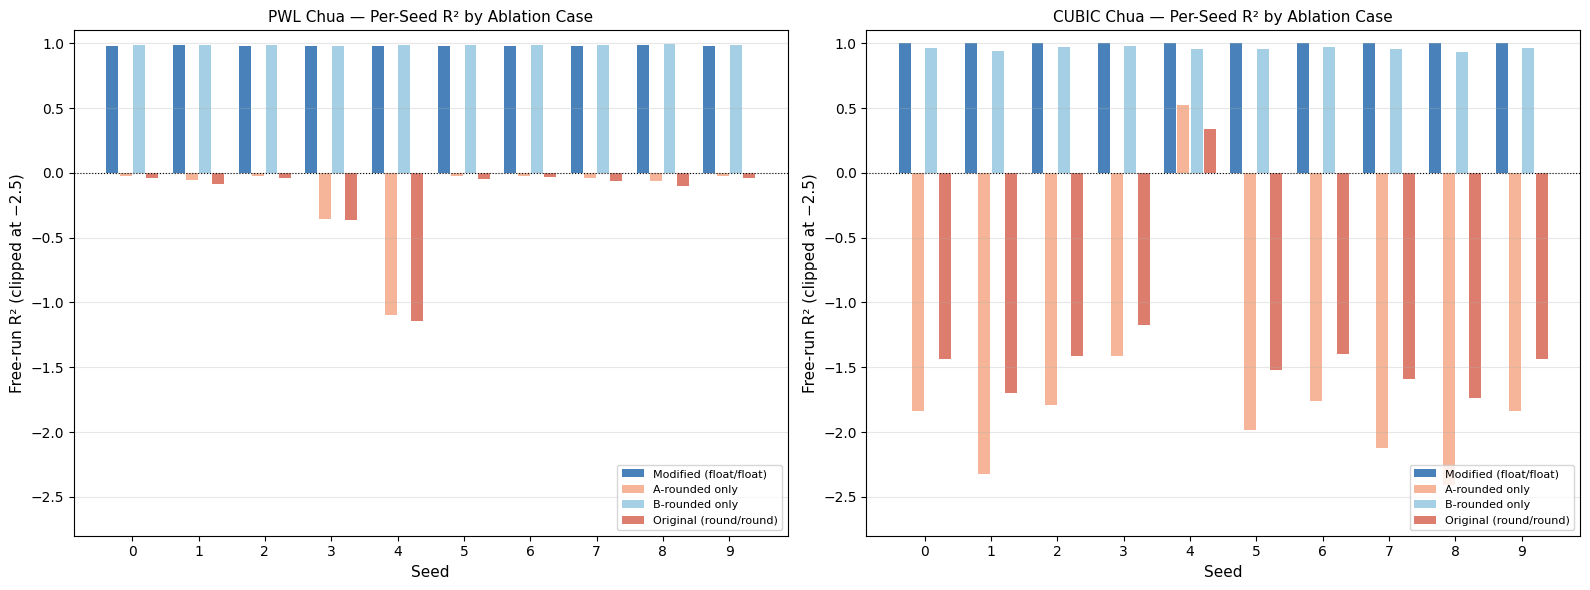

Saved: ablation_per_seed.png


In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12 — PER-SEED R² DETAIL PLOT
# ═══════════════════════════════════════════════════════════════════

fig2, axes = plt.subplots(1, 2, figsize=(16, 6))

for pi, system in enumerate(SYSTEMS):
    ax = axes[pi]
    seeds = np.arange(N_SEEDS)
    n_cases = len(CASES)
    bar_w  = 0.8 / n_cases

    for ci, (case_label, ra, rb, col) in enumerate(CASES):
        case_plain = case_label.replace('\n', ' ')
        sub = df[(df['system'] == system) & (df['case'] == case_plain)]
        sub = sub.sort_values('seed')
        r2s = sub['r2'].values
        # Clip extreme negatives for display
        r2s_clipped = np.clip(r2s, -2.5, 1.0)

        xpos = seeds + (ci - n_cases/2 + 0.5) * bar_w
        ax.bar(xpos, r2s_clipped, bar_w * 0.9,
               color=col, alpha=0.82,
               label=case_label.replace('\n',' '))

    ax.axhline(0, color='k', lw=0.8, ls=':')
    ax.set_xlabel('Seed', fontsize=11)
    ax.set_ylabel('Free-run R² (clipped at −2.5)', fontsize=11)
    ax.set_title(f'{system.upper()} Chua — Per-Seed R² by Ablation Case', fontsize=11)
    ax.set_xticks(seeds)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(-2.8, 1.1)

plt.tight_layout()
plt.savefig('ablation_per_seed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_per_seed.png')

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13 — EXCEL EXPORT
# ═══════════════════════════════════════════════════════════════════

with pd.ExcelWriter('RC_HAVOK_Ablation_Results.xlsx', engine='openpyxl') as writer:

    # Sheet 1: Full per-seed results
    df.to_excel(writer, sheet_name='Per_Seed_Results', index=False)

    # Sheet 2: Summary statistics
    df_summary.to_excel(writer, sheet_name='Summary_Statistics', index=False)

    # Sheet 3: Frequency shift and eigenvalue data
    eig_cols = ['system','seed','lam_max_float','freq_float',
                'lam_max_round','freq_round','freq_shift',
                'B_norm_float','B_norm_round','max_B_float',
                'A_float_str','A_round_str','B_float_str','B_round_str']
    df_eig = df[df['case']=='Modified (float/float)'][eig_cols].copy()
    df_eig.to_excel(writer, sheet_name='Eigenvalue_Analysis', index=False)

print('Saved: RC_HAVOK_Ablation_Results.xlsx')

Saved: RC_HAVOK_Ablation_Results.xlsx


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14 — PAPER-READY RESULT STATEMENT
# ═══════════════════════════════════════════════════════════════════

print('=' * 65)
print('PAPER-READY RESULT STATEMENT')
print('=' * 65)

for system in SYSTEMS:
    sub = df_summary[df_summary['System'] == system.upper()]
    rows = {row['Case']: row for _, row in sub.iterrows()}

    ff = rows.get('Modified (float/float)', {})
    rr = rows.get('Original (round/round)', {})
    af = rows.get('A-rounded only', {})
    bf = rows.get('B-rounded only', {})

    print(f'\n{system.upper()} Chua:')
    print(f'  Modified  (float/float): Median R² = {ff.get("R2_median", float("nan")):.5f}, '
          f'Mean±SD = {ff.get("R2_mean", float("nan")):.5f} ± {ff.get("R2_std", float("nan")):.5f}, '
          f'RMSE = {ff.get("RMSE_median", float("nan")):.2e}, '
          f'Div = {ff.get("N_diverged", "?")}/{N_SEEDS}')
    print(f'  A-rounded only:          Median R² = {af.get("R2_median", float("nan")):.5f}, '
          f'Mean±SD = {af.get("R2_mean", float("nan")):.5f} ± {af.get("R2_std", float("nan")):.5f}, '
          f'Div = {af.get("N_diverged", "?")}/{N_SEEDS}')
    print(f'  B-rounded only:          Median R² = {bf.get("R2_median", float("nan")):.5f}, '
          f'Mean±SD = {bf.get("R2_mean", float("nan")):.5f} ± {bf.get("R2_std", float("nan")):.5f}, '
          f'Div = {bf.get("N_diverged", "?")}/{N_SEEDS}')
    print(f'  Original  (round/round): Median R² = {rr.get("R2_median", float("nan")):.5f}, '
          f'Mean±SD = {rr.get("R2_mean", float("nan")):.5f} ± {rr.get("R2_std", float("nan")):.5f}, '
          f'Div = {rr.get("N_diverged", "?")}/{N_SEEDS}')

print()
print('─── Narrative summary (for Results section draft) ───')
print()
print("""
INTERPRETATION TEMPLATE (update with actual numbers after execution):

This ablation is designed to determine whether A-rounding or B-rounding
is the dominant source of reconstruction degradation in Original RC-HAVOK.

Expected qualitative pattern:
  - If A-rounded-only R² ≈ Original (round/round): A-rounding is primary damage.
  - If B-rounded-only R² ≈ Modified (float/float): B-rounding is secondary.

Once results are available, use wording such as:
  'The results suggest that A-matrix rounding is the dominant source of
   degradation, as the A-rounded-only configuration produced R² consistent
   with the fully rounded Original case [numbers here].'

Wording conventions:
  - Use 'supports' / 'suggests' — not 'proves' / 'confirms'
  - Use 'bounded double-scroll-like dynamics' — not 'confirmed chaos'
  - Report median R² and mean ± SD separately
  - Replace [numbers here] with actual Cell 9 output before manuscript use
""")

PAPER-READY RESULT STATEMENT

PWL Chua:
  Modified  (float/float): Median R² = 0.98180, Mean±SD = 0.98151 ± 0.00157, RMSE = 3.18e-04, Div = 0/10
  A-rounded only:          Median R² = -0.03354, Mean±SD = -0.17325 ± 0.32338, Div = 0/10
  B-rounded only:          Median R² = 0.98541, Mean±SD = 0.98619 ± 0.00286, Div = 0/10
  Original  (round/round): Median R² = -0.05480, Mean±SD = -0.19448 ± 0.33022, Div = 0/10

CUBIC Chua:
  Modified  (float/float): Median R² = 0.99963, Mean±SD = 0.99963 ± 0.00005, RMSE = 2.99e-05, Div = 0/10
  A-rounded only:          Median R² = -1.83711, Mean±SD = -1.69680 ± 0.78880, Div = 0/10
  B-rounded only:          Median R² = 0.96283, Mean±SD = 0.95914 ± 0.01233, Div = 0/10
  Original  (round/round): Median R² = -1.43905, Mean±SD = -1.30770 ± 0.56857, Div = 0/10

─── Narrative summary (for Results section draft) ───


INTERPRETATION TEMPLATE (update with actual numbers after execution):

This ablation is designed to determine whether A-rounding or B-rounding
i

---
## End of Notebook

### Output files
| File | Contents |
|------|----------|
| `ablation_summary.png` | 6-panel summary: R² bars, RMSE bars, freq shift, B norm |
| `ablation_per_seed.png` | Per-seed R² bars, all 4 cases, both systems |
| `RC_HAVOK_Ablation_Results.xlsx` | 3 sheets: per-seed, summary, eigenvalue analysis |

### Expected qualitative results (hypotheses — not guaranteed numbers)
- **Modified (float/float):** Should perform best across all seeds.
- **A-rounded only:** Expected close to Original (round/round) if A-rounding is the dominant damage source — this is the key mechanistic hypothesis.
- **B-rounded only:** Expected closer to Modified (float/float) if B-rounding is secondary.
- **Original (round/round):** Expected worst performance.

> Actual numerical values depend on evaluation window, seed set, and system variant.  
> Do **not** interpret based on numbers from prior notebooks — read from Cell 14 output.

### Citation note
This notebook is part of the study extending:
> Bingol & Gunay, *Data-Driven Modeling of the Koopman-Oriented Chua Circuit Based on Reservoir Computers*, ISCAS 2025.